In [3]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, accuracy_score


In [4]:
# Load the uploaded Excel file to examine its structure
file_path = "all_action.xlsx"
xls = pd.ExcelFile(file_path)

# Display sheet names
sheet_names = xls.sheet_names

# Load the first sheet to examine the structure
df = xls.parse(sheet_names[0])
df.head()


,Unnamed: 0,SAC,PPO,GRPO,best_strategy
0,2019-01-02,risk_parity,risk_parity,paa,risk_parity
1,2019-01-31,risk_parity,risk_parity,risk_parity,risk_parity
2,2019-03-01,risk_parity,risk_parity,risk_parity,risk_parity
3,2019-03-29,risk_parity,risk_parity,risk_parity,risk_parity
4,2019-04-29,risk_parity,risk_parity,risk_parity,min_var


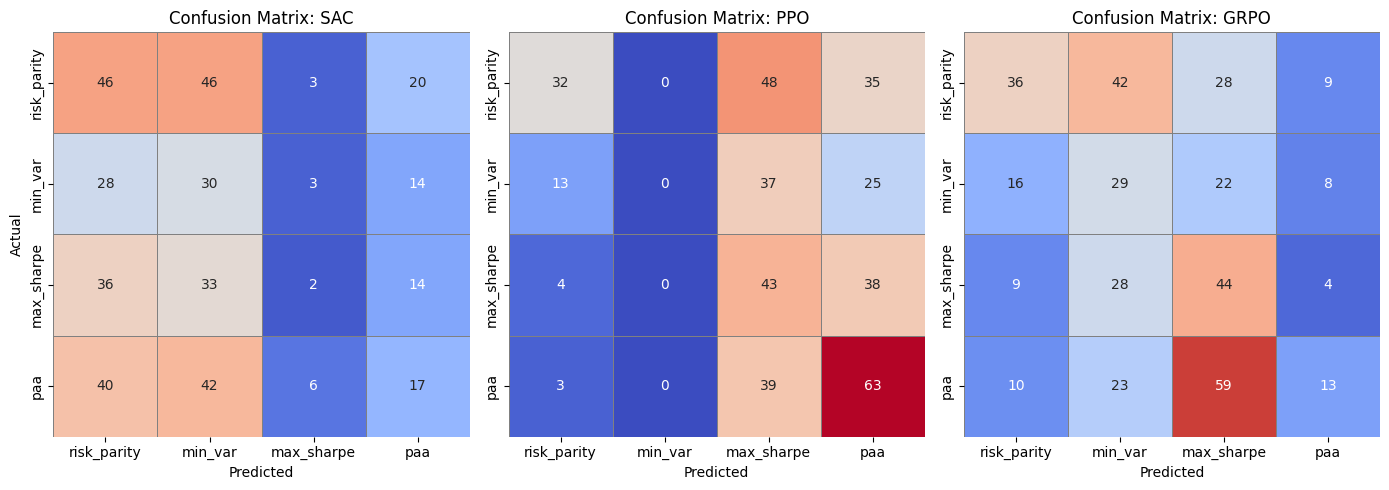

In [6]:
true_labels = df['best_strategy']
algorithms = ['SAC', 'PPO', 'GRPO']

# 모든 confusion matrix 생성 후 최대값 계산
cms = []
max_val = 0
for algo in algorithms:
    preds = df[algo]
    cm = confusion_matrix(true_labels, preds, labels=true_labels.unique())
    cms.append(cm)
    max_val = max(max_val, cm.max())

# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, algo in enumerate(algorithms):
    sns.heatmap(cms[i], annot=True, fmt='d',
                xticklabels=true_labels.unique(),
                yticklabels=true_labels.unique(),
                ax=axes[i], cmap="coolwarm", cbar=False,
                linewidths=0.5, linecolor='gray',
                vmin=0, vmax=max_val)  # 동일한 색상 범위 적용
    axes[i].set_title(f'Confusion Matrix: {algo}')
    axes[i].set_xlabel('Predicted')
    if i == 0:
        axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("/workspace/figure/confusion_matrix.png", dpi=600, bbox_inches='tight')
plt.show()

In [17]:

# Initialize storage for performance reports
reports = {}

# Get sorted list of labels for consistency
labels = sorted(df['best_strategy'].unique())

# Compute classification report for each model
for algo in algorithms:
    y_true = df['best_strategy']
    y_pred = df[algo]
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    overall_accuracy = accuracy_score(y_true, y_pred)
    reports[algo] = {
        'accuracy': overall_accuracy,
        'macro avg': report['macro avg'],
        'weighted avg': report['weighted avg']
    }

# Create summary DataFrame
summary_df = pd.DataFrame({
    model: {
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Macro Precision': f"{metrics['macro avg']['precision']:.4f}",
        'Macro Recall': f"{metrics['macro avg']['recall']:.4f}",
        'Macro F1-Score': f"{metrics['macro avg']['f1-score']:.4f}",
        'Weighted Precision': f"{metrics['weighted avg']['precision']:.4f}",
        'Weighted Recall': f"{metrics['weighted avg']['recall']:.4f}",
        'Weighted F1-Score': f"{metrics['weighted avg']['f1-score']:.4f}"
    }
    for model, metrics in reports.items()
}).T


In [18]:
summary_df

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Weighted Precision,Weighted Recall,Weighted F1-Score
SAC,0.2500,0.2274,0.2464,0.2133,0.2362,0.2500,0.2218
PPO,0.3632,0.3160,0.3460,0.2995,0.3520,0.3632,0.3232
GRPO,0.3211,0.3537,0.3353,0.3096,0.3703,0.3211,0.3096
